In [21]:
pip install plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.9 MB 4.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.0 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.9 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 4.0 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 4.0 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 3.9 MB/s eta 0:00:01
   ---------------

In [20]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.Collecting missingno



In [45]:
# Import
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import plotly.express as px
%matplotlib inline
import missingno as msno

In [8]:
airBnb_df=pd.read_csv("E:/Python/Airbnb NYC 2019.csv")
airBnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# dataset rows and column count

In [9]:
airBnb_df.shape

(48895, 16)

In [10]:
airBnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [11]:
duplicate_count=airBnb_df.duplicated().value_counts()
duplicate_count

False    48895
Name: count, dtype: int64

# Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
null_count=airBnb_df.isnull().sum().sort_values(ascending=False)  #use for NAN count
null_count

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
id                                    0
host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [27]:
plt.figure(figsize=(14,7))
sns.countplot(x=airBnb_df.duplicated())
plt.title('Visualisation of duplicated value',fontsize=25)
plt.ylabel('Count of Duplicate Values',fontsize=20)


Text(0, 0.5, 'Count of Duplicate Values')

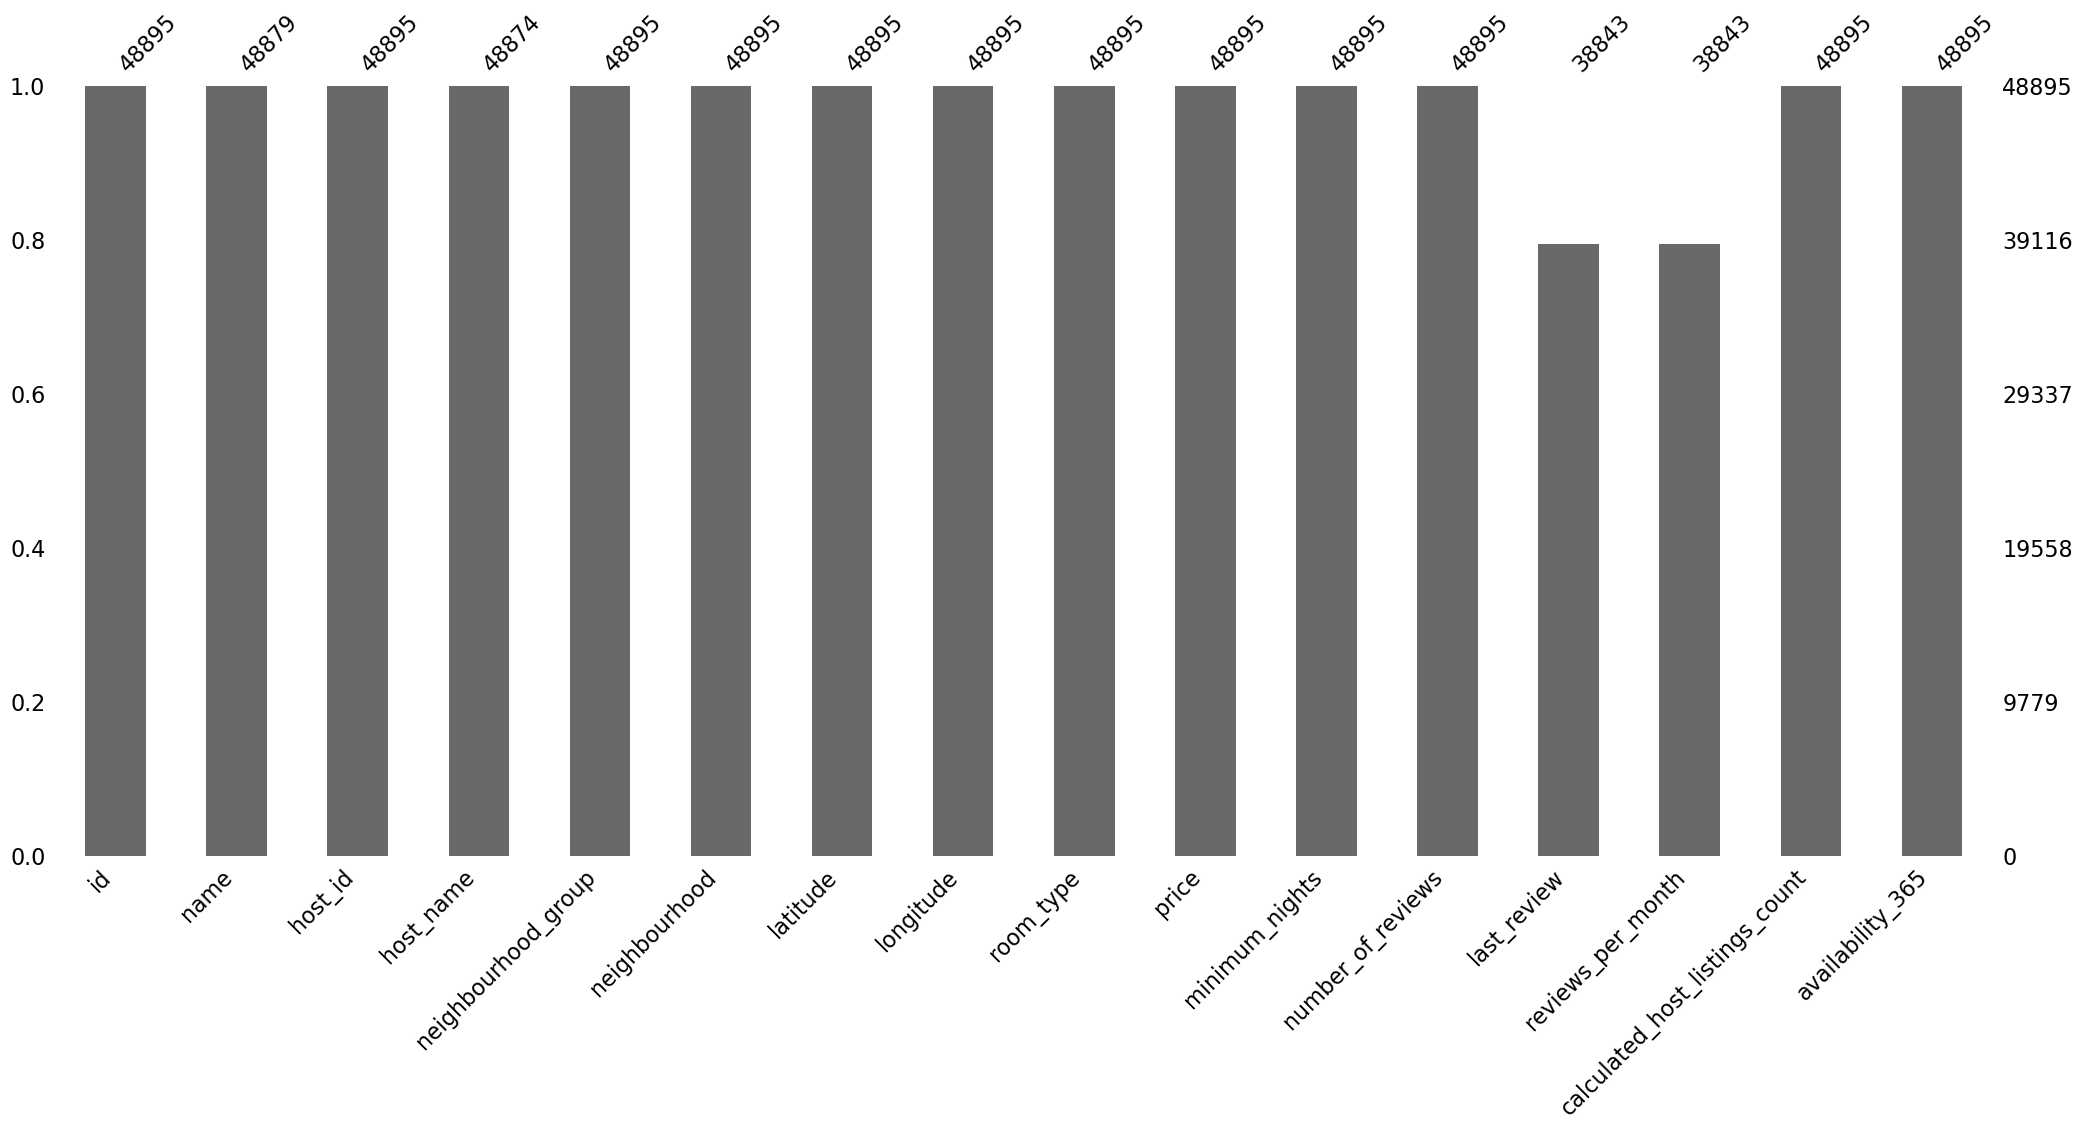

In [26]:
import missingno as msno
msno.bar(airBnb_df)
plt.show()

# What did you know about your dataset?

The given dataset is of AirBnb and we have to analyse and explore this dataset to discover important facrtors which affects the customer booking. The above dataset has 48895 rows and 16 coulumns.The duplicate value count is Zero rows and Zero columns. There are 4 columns in dataset which have missing values and those columns are last_review, reviews_per_month, host_name and name.

# understanding your variables

In [29]:
airBnb_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [30]:
# dataset describe
airBnb_df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


# variable description

id--->Airbnb's unique identifier for the listing,

name--->Name of the listing,

host_id--->Airbnb's unique identifier for the host/user,

host_name---->Name of the host. Usually just the first name(s),

neighbourhood_group------>The neighbourhood group as geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles.

neighbourhood----> Neighbourhood

latitude----> Uses the World Geodetic System (WGS84) projection for latitude and longitude.

longitude-----> Uses the World Geodetic System (WGS84) projection for latitude and longitude.

room_type----> [Entire home/apt|Private room|Shared room|Hotel]

All homes are grouped into the following three room types:

Entire place Private room Shared room Entire place Entire places are best if you're seeking a home away from home. With an entire place, you'll have the whole space to yourself. This usually includes a bedroom, a bathroom, a kitchen, and a separate, dedicated entrance. Hosts should note in the description if they'll be on the property or not (ex: "Host occupies first floor of the home"), and provide further details on the listing.

Private rooms Private rooms are great for when you prefer a little privacy, and still value a local connection. When you book a private room, you'll have your own private room for sleeping and may share some spaces with others. You might need to walk through indoor spaces that another host or guest may occupy to get to your room.

Shared rooms Shared rooms are for when you don't mind sharing a space with others. When you book a shared room, you'll be sleeping in a space that is shared with others and share the entire space with other people. Shared rooms are popular among flexible travelers looking for new friends and budget-friendly stays.

price----->daily price in local currency

minimum_nights---->minimum number of night stay for the listing (calendar rules may be different)

number_of_reviews--->The number of reviews the listing has

last_review---->The date of the last/newest review

reviews_per_month----->The number of reviews the listing has per month

calculated_host_listings_count----->The number of listings the host has in the current scrape, in the city/region geography.

availability_365----> avaliability_x. The availability of the listing x days in the future as determined by the calendar. Note a listing may not be available because it has been booked by a guest or blocked by the host.

# check unique values for each variables

In [31]:
print(airBnb_df.apply(lambda col: col.unique()))

id                                [2539, 2595, 3647, 3831, 5022, 5099, 5121, 517...
name                              [Clean & quiet apt home by the park, Skylit Mi...
host_id                           [2787, 2845, 4632, 4869, 7192, 7322, 7356, 896...
host_name                         [John, Jennifer, Elisabeth, LisaRoxanne, Laura...
neighbourhood_group               [Brooklyn, Manhattan, Queens, Staten Island, B...
neighbourhood                     [Kensington, Midtown, Harlem, Clinton Hill, Ea...
latitude                          [40.64749, 40.75362, 40.80902, 40.68514, 40.79...
longitude                         [-73.97237, -73.98377, -73.9419, -73.95976, -7...
room_type                              [Private room, Entire home/apt, Shared room]
price                             [149, 225, 150, 89, 80, 200, 60, 79, 135, 85, ...
minimum_nights                    [1, 3, 10, 45, 2, 5, 4, 90, 7, 14, 60, 29, 30,...
number_of_reviews                 [9, 45, 0, 270, 74, 49, 430, 118, 160, 53,

In [32]:
airBnb_df1=airBnb_df.copy()

In [34]:
null_columns=['last_review','reviews_per_month']
for columns in null_columns:
  airBnb_df1.fillna({columns: 0}, inplace=True)

In [35]:
airBnb_df1.fillna({"host_name": "other"}, inplace=True)

In [36]:
airBnb_df1.fillna({"name": "other"}, inplace=True)

In [37]:
airBnb_df1.isna().sum().sort_values(ascending=True)

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [38]:
count_manhattan= (airBnb_df1['neighbourhood_group'] == 'Manhattan').sum()
count_manhattan

21661

In [39]:
avg_price=airBnb_df1.groupby('neighbourhood_group')['price'].mean()
avg_price

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

In [42]:
unavailable_ids = airBnb_df1[airBnb_df1['availability_365'] == 0]['id']
unavailable_ids

4            5022
6            5121
8            5203
14           6090
20           7801
           ...   
48550    36313048
48731    36410519
48756    36419441
48760    36420725
48779    36424776
Name: id, Length: 17533, dtype: int64

## What all manipulations have you done and insights you found?
Checked that there are no duplicate columns,but some columns has missing values.So,numerical missing values like last_review and reviews_per_month are filled with zero and categorical missing values like name and host_name are filled with "Other" value,and then checked that there are no more missing values in the dataframe.

## 4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

## which types of rooms are mostly available

In [43]:
room_value_counts=airBnb_df1['room_type'].value_counts()
room_value_counts

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

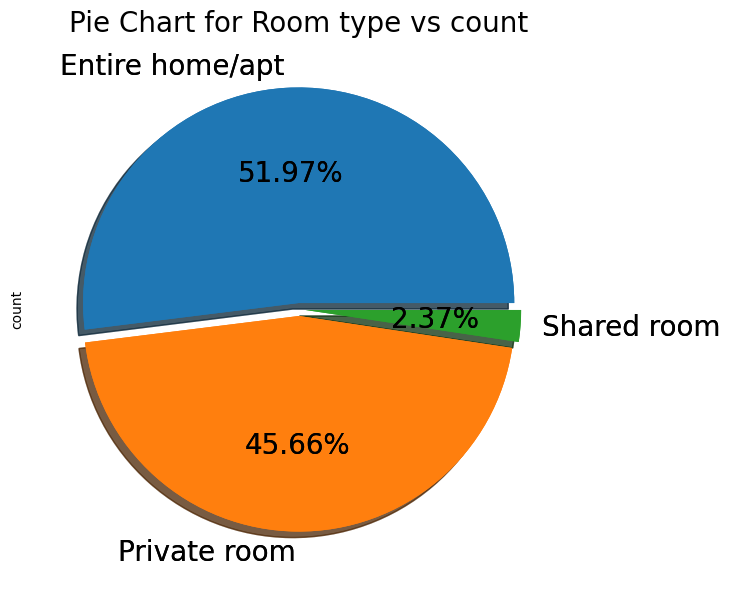

In [51]:
#piechart Vizualization
#plt.figure(figsize=(6,6))
room_value_counts.plot.pie(explode=[0.03, 0.03,0.03], autopct='%1.2f%%', shadow=True, figsize=(10,7),fontsize=20)
plt.title('Pie Chart for Room type vs count',fontsize = 20)
plt.show()

## 1. Why did you pick the specific chart?

 We use pie chart because pie chart gives simple and easy to understand picture that shows which type of property has highest number.

## 3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason?

In [53]:
room_type_counts_neighbourhood_grp=airBnb_df1.groupby('neighbourhood_group')['id'].count()
room_type_counts_neighbourhood_grp

neighbourhood_group
Bronx             1091
Brooklyn         20104
Manhattan        21661
Queens            5666
Staten Island      373
Name: id, dtype: int64

from the above data insights we found that Bronx and staten island are underlisted,and entire home /apt rental price is 2.4 times more than that of private rooms.Airbnb can launch host aquisition campaign targetting entire home/apt in those areas.

# Listing by neighbourhood_group

In [54]:
Listing_counts_neighbourhood_grp=airBnb_df1.groupby('neighbourhood_group')['id'].count()
Listing_counts_neighbourhood_grp

neighbourhood_group
Bronx             1091
Brooklyn         20104
Manhattan        21661
Queens            5666
Staten Island      373
Name: id, dtype: int64

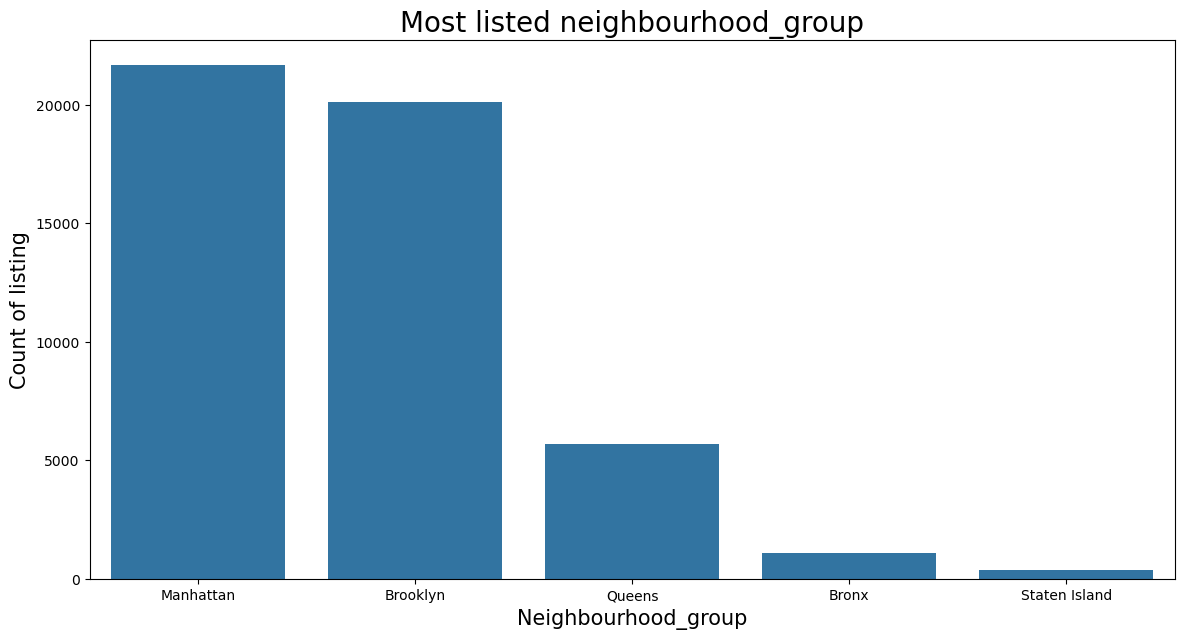

In [64]:
plt.figure(figsize=(14,7))
sorted_listing_counts = Listing_counts_neighbourhood_grp.sort_values(ascending=False)
ax=sns.barplot(x=sorted_listing_counts.index, y=sorted_listing_counts.values, order=sorted_listing_counts.index)
plt.title('Most listed neighbourhood_group', fontsize=20)
plt.ylabel('Count of listing', fontsize=15)
plt.xlabel('Neighbourhood_group', fontsize=15)
plt.show()

## average price per neighbourhood_group

In [57]:
avg_price_neighbourhood_group=airBnb_df1.groupby('neighbourhood_group')['price'].mean()
avg_price_neighbourhood_group

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

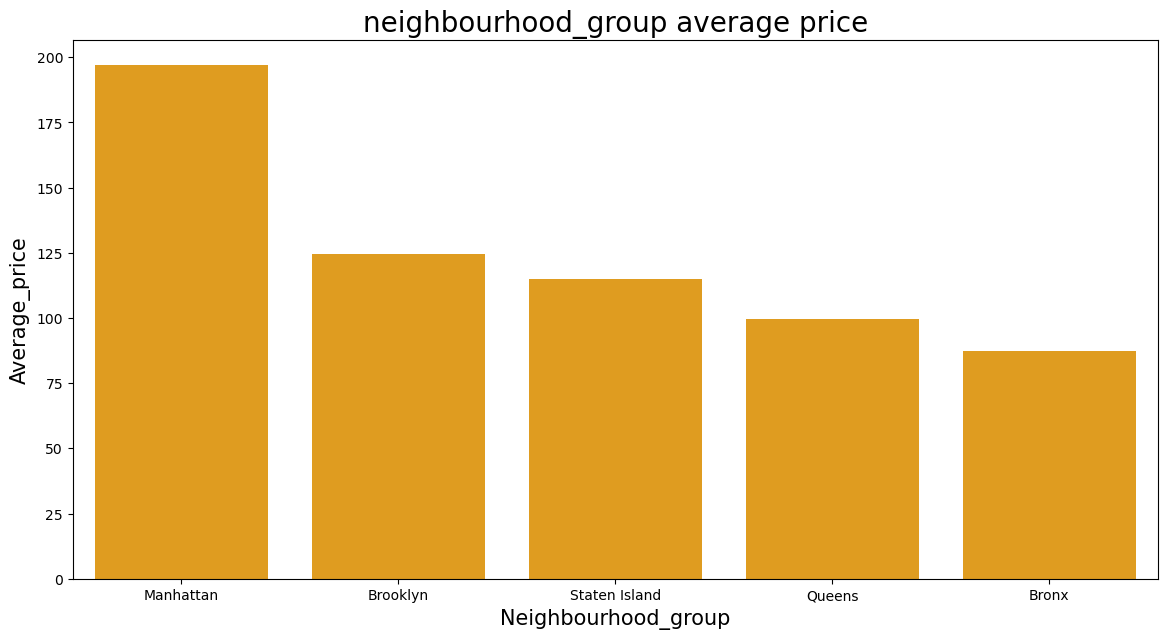

In [58]:
plt.figure(figsize=(14,7))
sorted_avg_price = avg_price_neighbourhood_group.sort_values(ascending=False)
sns.barplot(x=sorted_avg_price.index, y=sorted_avg_price.values, order=sorted_avg_price.index,color="orange")
plt.title('neighbourhood_group average price', fontsize=20)
plt.ylabel('Average_price', fontsize=15)
plt.xlabel('Neighbourhood_group', fontsize=15)
plt.show()

## What insights did you get from this chart?

Manhattan group's average listing price is the highest and Bronx's average listing price is the lowest.

## Average price by room_type

In [60]:
avg_room_type_price=airBnb_df1.groupby('room_type')['price'].mean()
avg_room_type_price

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

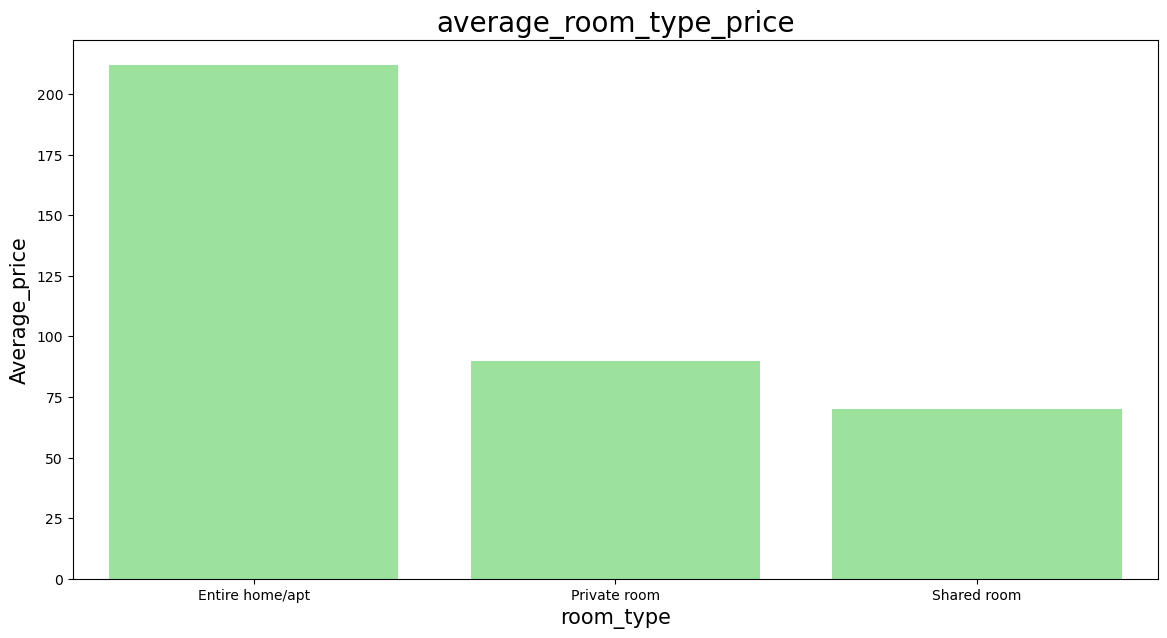

In [63]:
plt.figure(figsize=(14,7))
sorted_avg_room_type_price = avg_room_type_price.sort_values(ascending=False)
ax=sns.barplot(x=avg_room_type_price.index, y=avg_room_type_price.values, order=avg_room_type_price.index,color="lightgreen")
plt.title('average_room_type_price', fontsize=20)
plt.ylabel('Average_price', fontsize=15)
plt.xlabel('room_type', fontsize=15)
plt.show()

### how this chart will help business to make profit?

This chart helps Airbnb in dynamic pricing, targeted marketing, host acquisition, and optimizing revenue by revealing price variations across room types and neighborhoods. It allows Airbnb to focus on high-value areas like Manhattan for 'Entire home/apt' listings and identify opportunities for growth in other areas.

In [65]:
avg_price_neighbourhood_group=airBnb_df1.groupby(['neighbourhood_group','room_type'])['price'].mean()
avg_price_neighbourhood_group

neighbourhood_group  room_type      
Bronx                Entire home/apt    127.506596
                     Private room        66.788344
                     Shared room         59.800000
Brooklyn             Entire home/apt    178.327545
                     Private room        76.500099
                     Shared room         50.527845
Manhattan            Entire home/apt    249.239109
                     Private room       116.776622
                     Shared room         88.977083
Queens               Entire home/apt    147.050573
                     Private room        71.762456
                     Shared room         69.020202
Staten Island        Entire home/apt    173.846591
                     Private room        62.292553
                     Shared room         57.444444
Name: price, dtype: float64

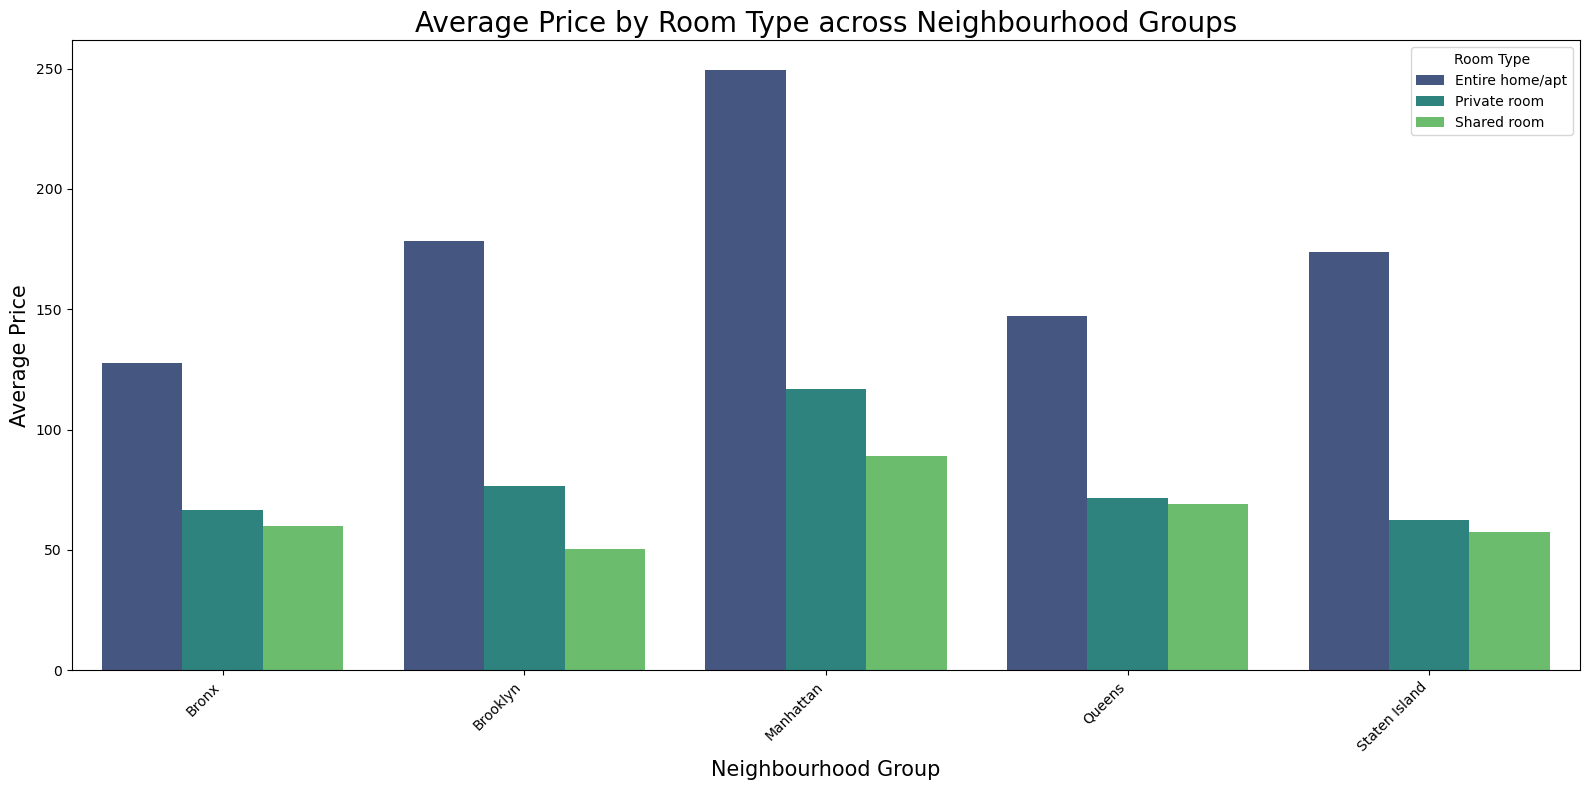

In [66]:
avg_price_neighbourhood_group_df = avg_price_neighbourhood_group.reset_index()

plt.figure(figsize=(16, 8))
sns.barplot(data=avg_price_neighbourhood_group_df, x='neighbourhood_group', y='price', hue='room_type', palette='viridis')
plt.title('Average Price by Room Type across Neighbourhood Groups', fontsize=20)
plt.xlabel('Neighbourhood Group', fontsize=15)
plt.ylabel('Average Price', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

The bar chart visualizes the average price for each room type across different neighborhood groups. We can observe that Manhattan consistently has the highest average prices across all room types, especially for 'Entire home/apt'. 'Entire home/apt' generally has a higher average price than 'Private room' and 'Shared room' in all neighborhood groups. 'Shared room' typically has the lowest average prices. The Bronx and Staten Island tend to have lower average prices compared to Manhattan and Brooklyn for all room types.

This chart helps Airbnb assess listing activity and host engagement across neighborhoods. Higher review rates suggest popular listings, guiding where to focus marketing and host support to boost overall platform activity and revenue.

In [67]:
bins = [0, 50, 100, 200, 500, np.inf]
labels = ['under $50', 'between $50-100', 'between $100-200', 'between $200-500', '$500+']
airBnb_df1['price_group'] = pd.cut(airBnb_df1['price'], bins=bins, labels=labels, right=False)
print(airBnb_df1['price_group'].value_counts().sort_index())

price_group
under $50            5027
between $50-100     16850
between $100-200    17233
between $200-500     8550
$500+                1235
Name: count, dtype: int64


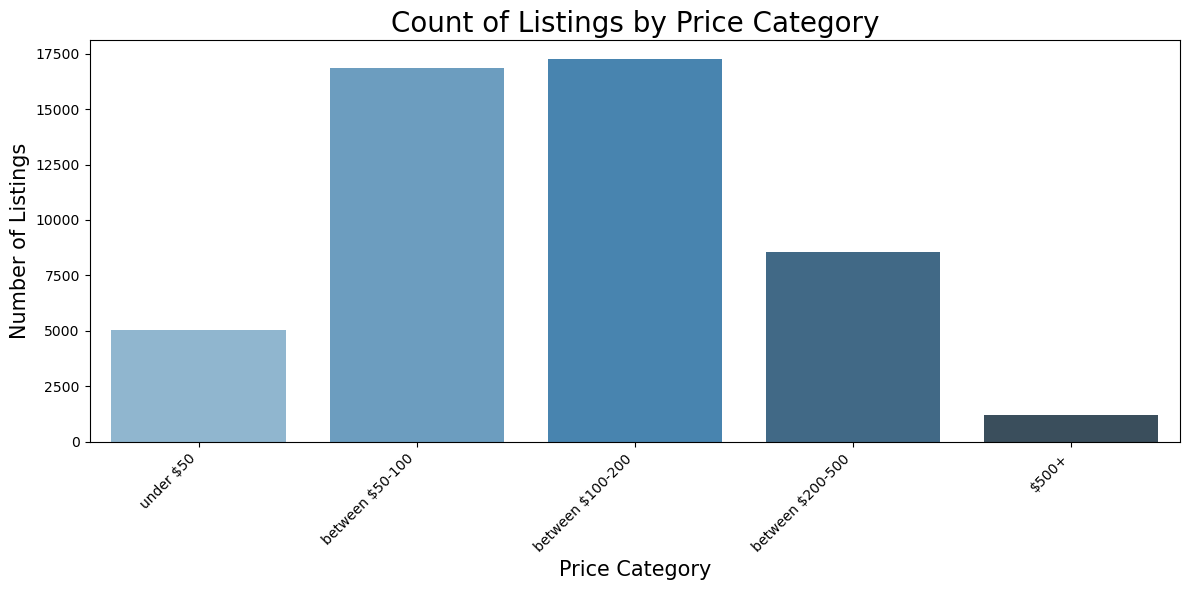

In [68]:
price_group_counts = airBnb_df1['price_group'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=price_group_counts.index, y=price_group_counts.values, hue=price_group_counts.index, palette='Blues_d', legend=False)
plt.title('Count of Listings by Price Category', fontsize=20)
plt.xlabel('Price Category', fontsize=15)
plt.ylabel('Number of Listings', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart helps Airbnb understand market demand across various price points. It allows them to identify popular price categories, guide hosts on competitive pricing, and tailor marketing strategies to attract different customer segments, optimizing booking volume and revenue.

In [69]:
bins = [1, 2, 3, 4, 5, 6, 7, 8, 30, np.inf]
labels = ['1 night', '2 nights', '3 nights', '4 nights', '5 nights', '6 nights', '7 nights', '8-30 nights', '30+ nights']

# Create the new categorical column for minimum_nights groups
# Using right=False means the bins are [a, b) - left inclusive, right exclusive
airBnb_df1['minimum_nights_group'] = pd.cut(
    airBnb_df1['minimum_nights'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True # To include values equal to the first bin (here, 1 night)
)

# Display the count of listings for each minimum_nights group
print(airBnb_df1['minimum_nights_group'].value_counts().sort_index())

minimum_nights_group
1 night        12720
2 nights       11696
3 nights        7999
4 nights        3303
5 nights        3034
6 nights         752
7 nights        2058
8-30 nights     2826
30+ nights      4507
Name: count, dtype: int64


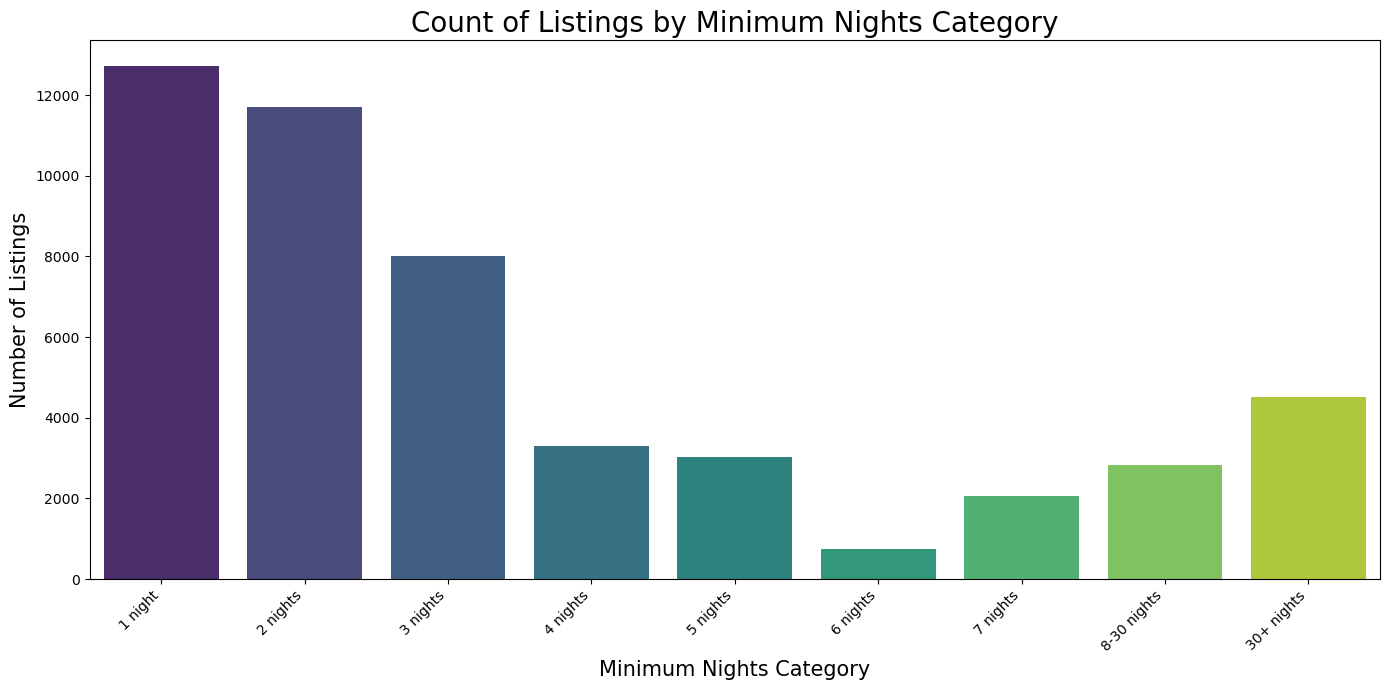

In [70]:
minimum_nights_counts = airBnb_df1['minimum_nights_group'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.barplot(x=minimum_nights_counts.index, y=minimum_nights_counts.values, hue=minimum_nights_counts.index, palette='viridis', legend=False)
plt.title('Count of Listings by Minimum Nights Category', fontsize=20)
plt.xlabel('Minimum Nights Category', fontsize=15)
plt.ylabel('Number of Listings', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart helps Airbnb understand booking patterns by showing popular stay durations. It enables them to guide hosts on optimal minimum night policies, tailor marketing for short-term vs. long-term stays, and identify opportunities to balance supply and demand for various trip lengths, ultimately boosting bookings and revenue.

In [71]:
avg_reviews_per_month_by_neighbourhood = airBnb_df1.groupby('neighbourhood_group')['reviews_per_month'].mean()
display(avg_reviews_per_month_by_neighbourhood)

neighbourhood_group
Bronx            1.475655
Brooklyn         1.049790
Manhattan        0.976782
Queens           1.567076
Staten Island    1.576381
Name: reviews_per_month, dtype: float64

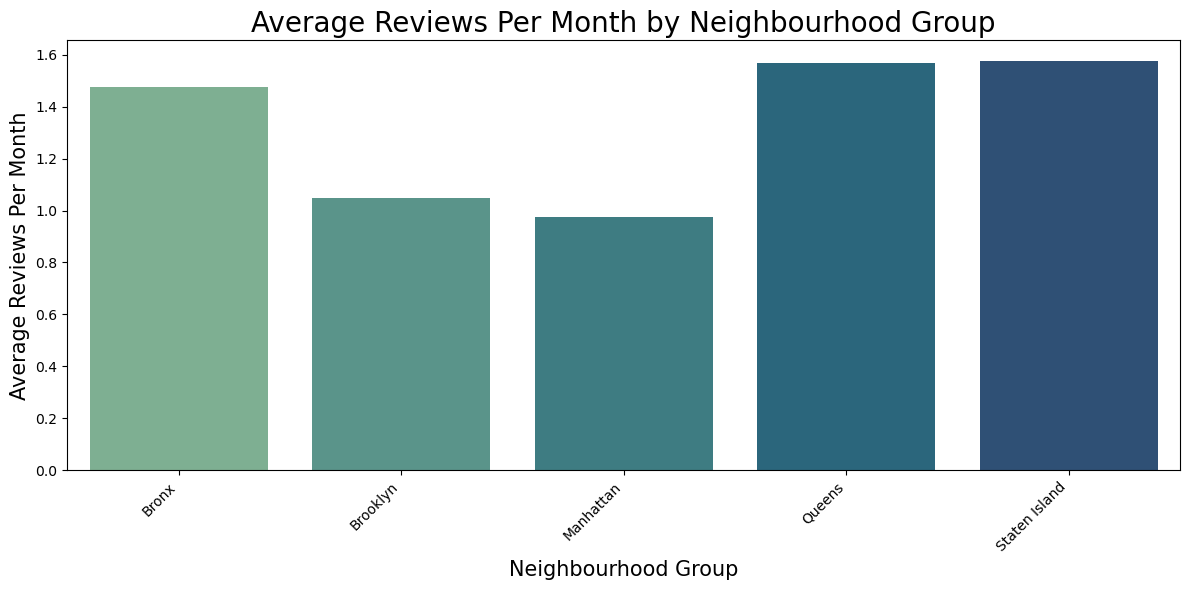

In [72]:
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_reviews_per_month_by_neighbourhood.index, y=avg_reviews_per_month_by_neighbourhood.values, hue=avg_reviews_per_month_by_neighbourhood.index, palette='crest', legend=False)
plt.title('Average Reviews Per Month by Neighbourhood Group', fontsize=20)
plt.xlabel('Neighbourhood Group', fontsize=15)
plt.ylabel('Average Reviews Per Month', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart helps Airbnb understand the activity and engagement levels of listings across different neighborhood groups. Higher average reviews per month can indicate more popular listings and active hosts, guiding Airbnb in targeting marketing, host support, and growth strategies to boost overall platform activity and revenue.

In [73]:
zero_availability_counts = airBnb_df1[airBnb_df1['availability_365'] == 0].groupby('neighbourhood_group')['id'].count()
display(zero_availability_counts)

neighbourhood_group
Bronx             177
Brooklyn         7844
Manhattan        8102
Queens           1368
Staten Island      42
Name: id, dtype: int64

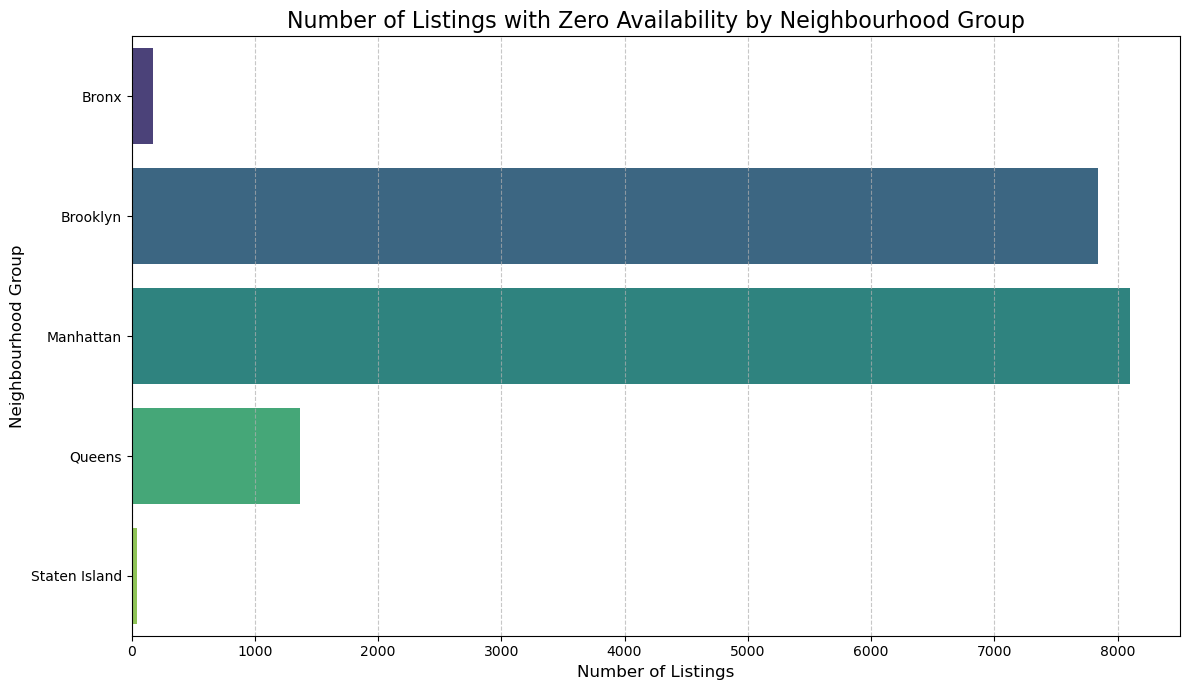

In [74]:
plt.figure(figsize=(12, 7))
sns.barplot(x=zero_availability_counts.values, y=zero_availability_counts.index, palette='viridis', hue=zero_availability_counts.index, legend=False)
plt.title('Number of Listings with Zero Availability by Neighbourhood Group', fontsize=16)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('Neighbourhood Group', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This chart highlights areas where demand outstrips supply, indicated by many listings with zero availability. Airbnb can leverage this by targeting host acquisition campaigns in these high-demand neighborhood groups and encouraging existing hosts to increase their availability to boost bookings and revenue.

In [75]:
top_10_neighbourhoods = airBnb_df1.groupby('neighbourhood')['id'].count().nlargest(10)
display(top_10_neighbourhoods)

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: id, dtype: int64

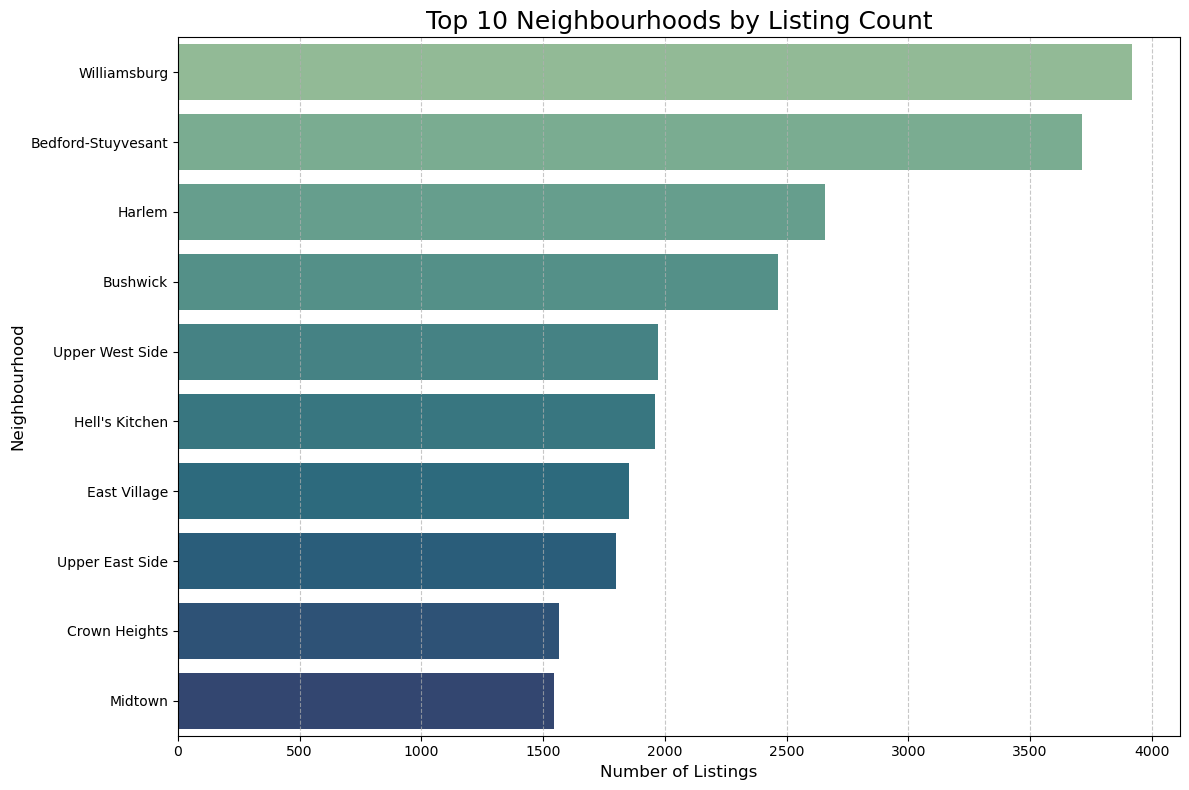

In [76]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_neighbourhoods.values, y=top_10_neighbourhoods.index, palette='crest', hue=top_10_neighbourhoods.index, legend=False)
plt.title('Top 10 Neighbourhoods by Listing Count', fontsize=18)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('Neighbourhood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This chart identifies Airbnb's most popular and saturated neighborhoods. It helps Airbnb focus marketing efforts on these high-volume areas, understand where most of its supply is concentrated, and strategically manage host support and community engagement in these key markets.